In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
X = train_df.drop(columns=[col for col in train_df.columns if 'BlendProperty' in col])
y = train_df[[col for col in train_df.columns if 'BlendProperty' in col]]

In [ ]:
X.fillna(0, inplace=True)
test_df = test_df[X.columns]
test_df.fillna(0, inplace=True)

/tmp/ipython-input-5-529354263.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(0, inplace=True)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

In [ ]:
models = []
mae_scores = []

for i in range(y.shape[1]):
    print(f"Training for {y.columns[i]}")

    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y.iloc[:, i], test_size=0.2, random_state=42)

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0
    )

    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_preds)
    mae_scores.append(mae)

    models.append(model)
    print(f"✅ MAE for {y.columns[i]}: {mae:.5f}")

Training for BlendProperty1
✅ MAE for BlendProperty1: 0.19670
Training for BlendProperty2
✅ MAE for BlendProperty2: 0.18676
Training for BlendProperty3
✅ MAE for BlendProperty3: 0.16217
Training for BlendProperty4
✅ MAE for BlendProperty4: 0.20846
Training for BlendProperty5
✅ MAE for BlendProperty5: 0.02436
Training for BlendProperty6
✅ MAE for BlendProperty6: 0.20504
Training for BlendProperty7
✅ MAE for BlendProperty7: 0.16274
Training for BlendProperty8
✅ MAE for BlendProperty8: 0.24131
Training for BlendProperty9
✅ MAE for BlendProperty9: 0.21729
Training for BlendProperty10
✅ MAE for BlendProperty10: 0.18473


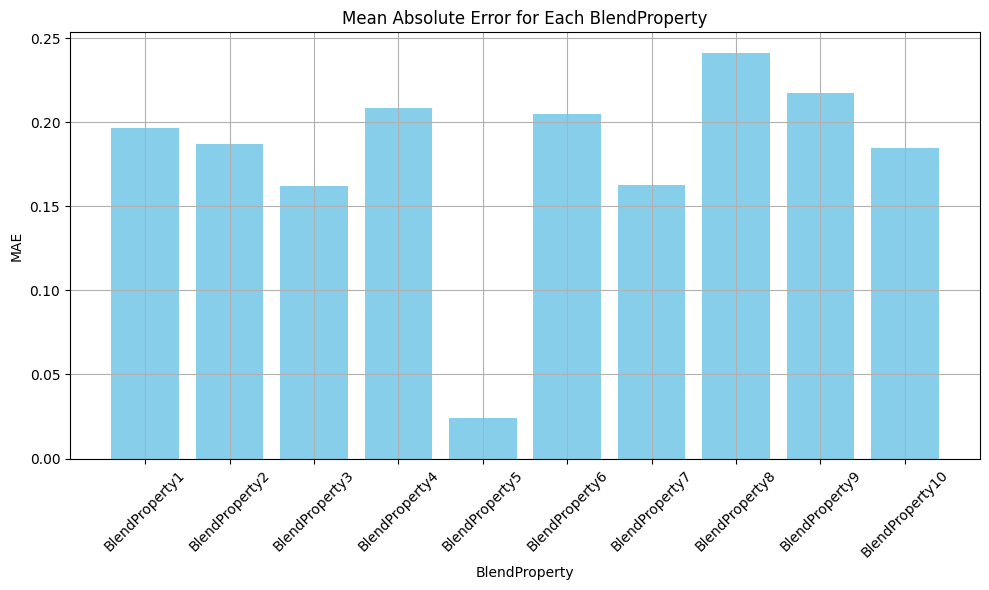

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(y.columns, mae_scores, color='skyblue')
plt.title("Mean Absolute Error for Each BlendProperty")
plt.xlabel("BlendProperty")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-9-4079178878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models[0].feature_importances_, y=X.columns, palette='viridis')


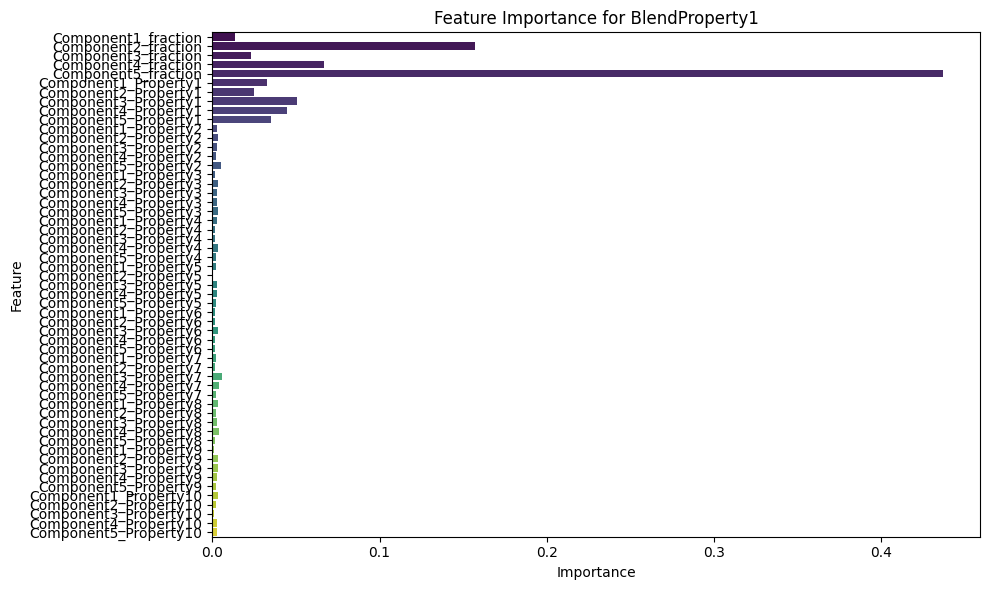

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=models[0].feature_importances_, y=X.columns, palette='viridis')
plt.title("Feature Importance for BlendProperty1")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

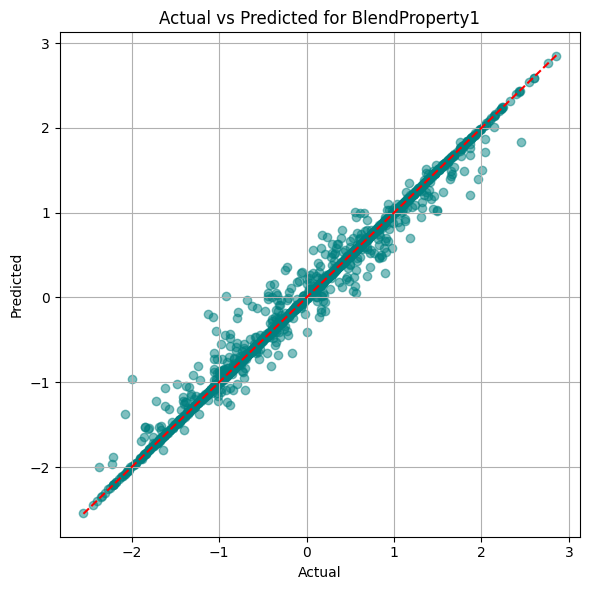

In [ ]:
y_true = y.iloc[:, 0]
y_pred = models[0].predict(X_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted for {y.columns[0]}")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
test_preds = np.column_stack([model.predict(test_scaled) for model in models])

In [ ]:
submission = pd.DataFrame(test_preds, columns=y.columns)
submission.insert(0, 'ID', range(1, len(test_df) + 1))
submission.to_csv("submission_xgb.csv", index=False)
print("✅ submission_xgb.csv saved!")

✅ submission_xgb.csv saved!
